In [338]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder



# ADVANCED DATA MANAGEMENT

In [339]:
df_origin = pd.read_csv('./Churn_Modelling.csv')
df = df_origin.copy()
df.head()
df = df.astype({'CreditScore': 'int64', 'Age': 'int64', 'Tenure': 'int64', 'NumOfProducts': 'int64', 'EstimatedSalary': 'float64'})
df = df.astype({'Exited': 'int64', 'HasCrCard': 'int64', 'IsActiveMember': 'int64'})

In [340]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


## Question 1: (8 points)

Identify the number of records (rows) and columns and list the data types of each column.
Get the descriptive analysis of the dataset on the numerical columns.
Write a few sentences about analysis of the dataset. How are they distributed?


In [341]:
#Q1
shape = df.shape
print("Number of rows:", shape[0])
print("Number of columns:", shape[1])
types = df.dtypes
print("Data types of each column:\n", types)

Number of rows: 10000
Number of columns: 14
Data types of each column:
 RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [342]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


1. There are 1000 records;
2. 

## Question 2: (8 points)

Visualize the outliers in plots for numerical fields and remove the outliers. 



<Axes: title={'center': 'ExpectedSalary'}>

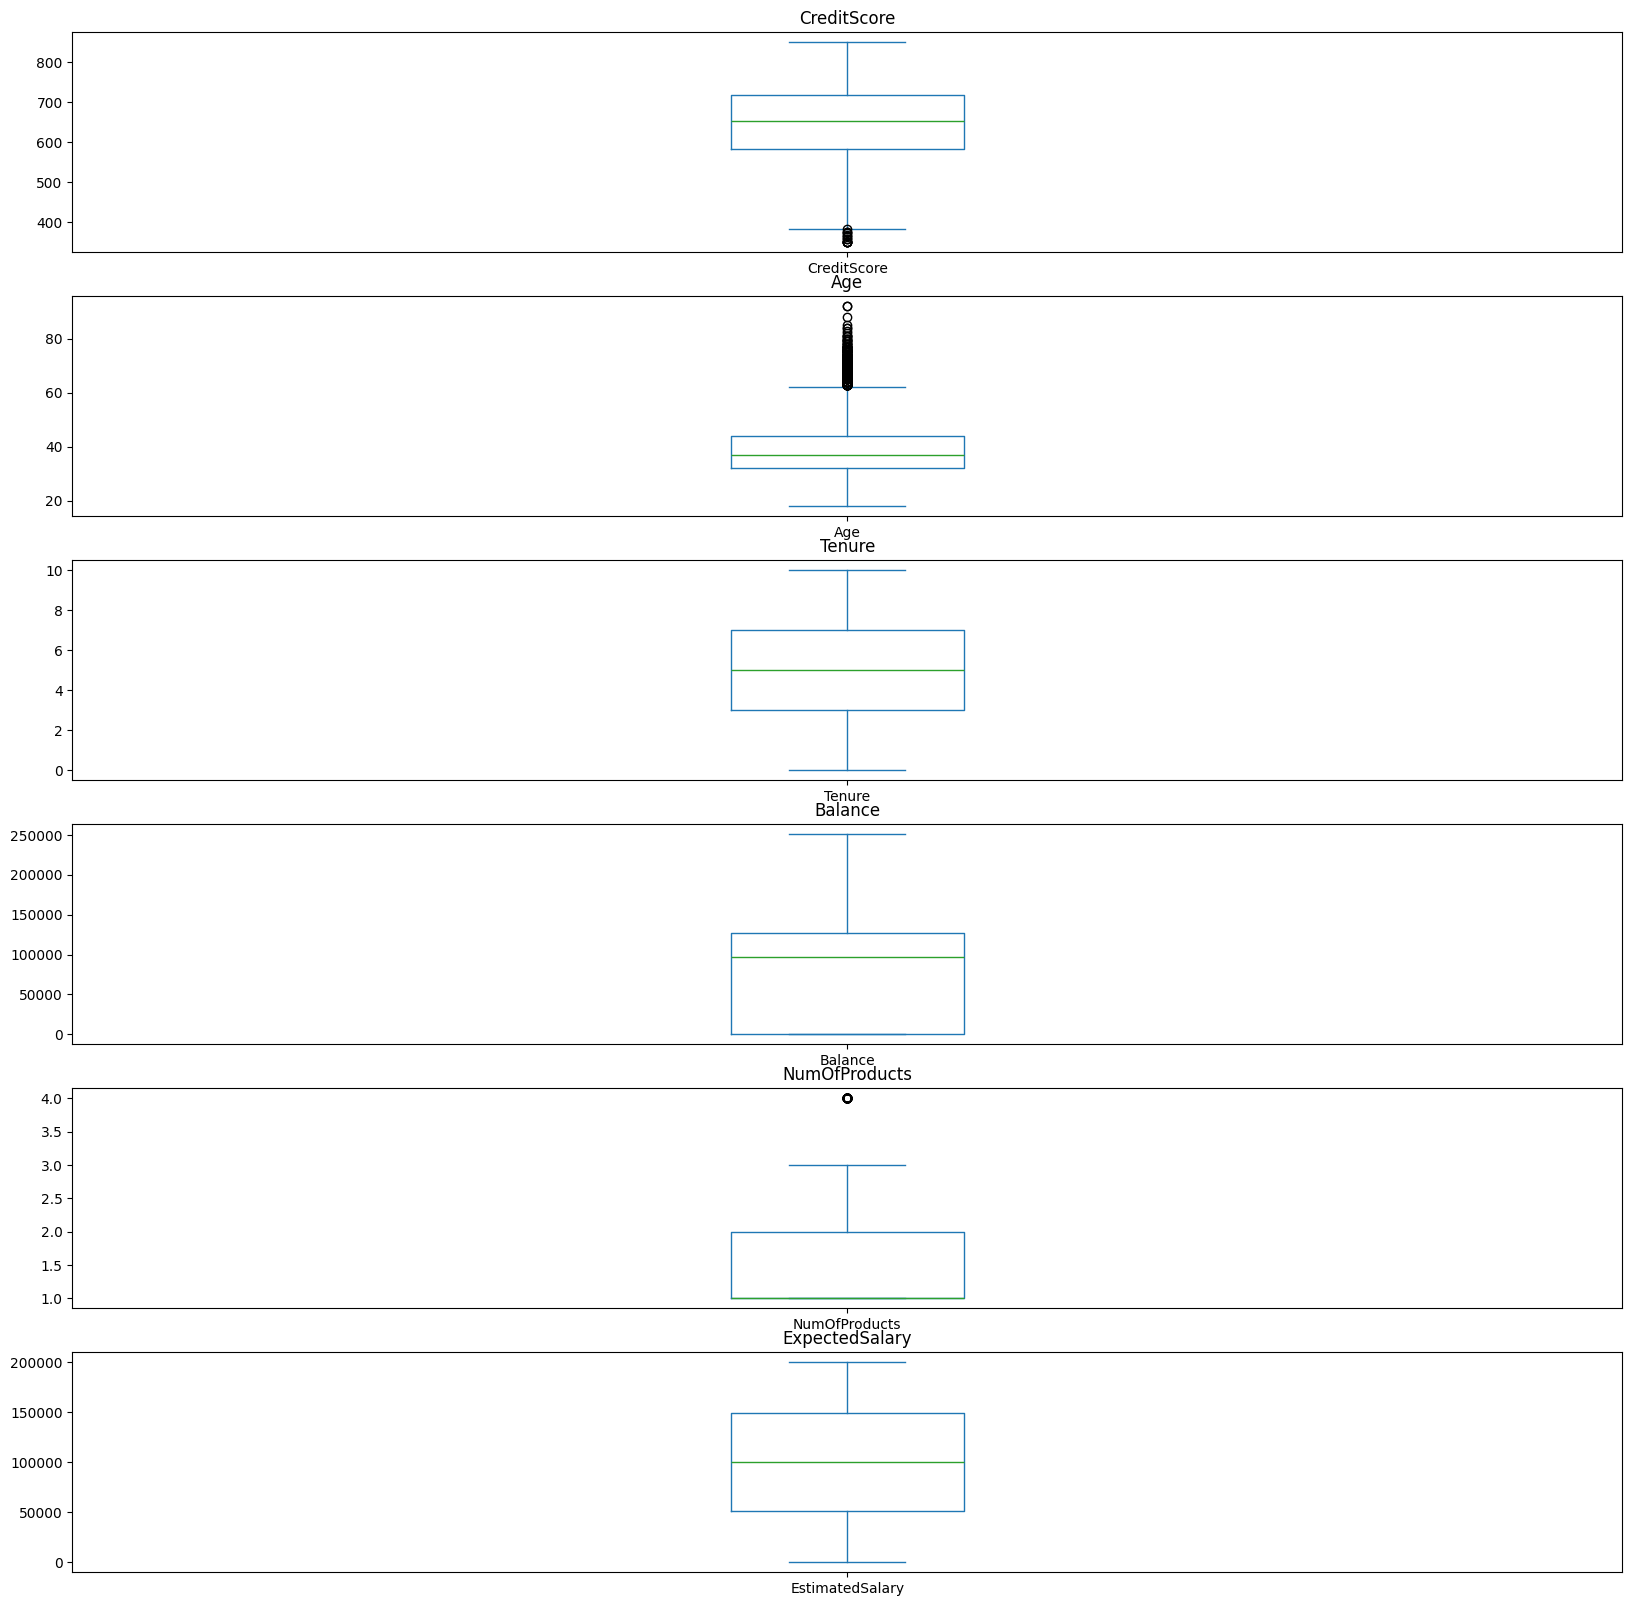

In [344]:
fig, ax = plt.subplots( 6, figsize=(20, 20))
df['CreditScore'].plot.box(ax=ax[0], title='CreditScore')
df['Age'].plot.box(ax=ax[1], title='Age')
df['Tenure'].plot.box(ax=ax[2], title='Tenure')
df['Balance'].plot.box(ax=ax[3], title='Balance')
df['NumOfProducts'].plot.box(ax=ax[4], title='NumOfProducts')
df['EstimatedSalary'].plot.box(ax=ax[5], title='ExpectedSalary')

In [345]:
s_credits = df['CreditScore']
percentile_25 = np.percentile(s_credits, 25)
percentile_75 = np.percentile(s_credits, 75)
iqr = percentile_75 - percentile_25
upper_bound = percentile_75 + 1.5 * iqr
lower_bound = percentile_25 - 1.5 * iqr
msk = (s_credits < lower_bound) | (s_credits > upper_bound)
s_credits_outliers = s_credits[(msk)]
s_scores_outliers_count = s_credits_outliers.count()
print("Number of outliers in 'CreditScore':", s_scores_outliers_count)

df.drop(s_credits_outliers.index, inplace=True)
df.shape



Number of outliers in 'CreditScore': 15


(9985, 14)

## Question 3: (6 points)

Check for the missing data and handle them. You must also explain your logic on how to handle the missing values.



In [346]:
df.isnull().sum()
print("There are no missing values in the dataset.")

There are no missing values in the dataset.



## Question 4: (5 points)

Identify the categorical data and encode them properly for machine learning


In [347]:
df_origin.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [348]:
df["Gender"].value_counts()
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})  
 
# df.head() 

In [349]:
df.info()

<class 'pandas.DataFrame'>
Index: 9985 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        9985 non-null   int64  
 1   CustomerId       9985 non-null   int64  
 2   Surname          9985 non-null   str    
 3   CreditScore      9985 non-null   int64  
 4   Geography        9985 non-null   str    
 5   Gender           9985 non-null   int64  
 6   Age              9985 non-null   int64  
 7   Tenure           9985 non-null   int64  
 8   Balance          9985 non-null   float64
 9   NumOfProducts    9985 non-null   int64  
 10  HasCrCard        9985 non-null   int64  
 11  IsActiveMember   9985 non-null   int64  
 12  EstimatedSalary  9985 non-null   float64
 13  Exited           9985 non-null   int64  
dtypes: float64(2), int64(10), str(2)
memory usage: 1.1 MB


In [350]:
df_origin["Geography"].value_counts()
# df = df.astype({'Geography': 'category'})

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [351]:
onehot_columns = ['Geography']
onehotencoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
onehotencoder.fit(df[onehot_columns])    


feature_names = onehotencoder.get_feature_names_out(onehot_columns)
feature_names
test = onehotencoder.transform(df[onehot_columns])
df[feature_names] = test
df = df.drop(onehot_columns, axis=1)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,2,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,3,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,4,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,5,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [352]:
df.to_csv('./cleaned_data.csv', index=False)

## Question 5: (3 points)

Calculate the Pearson correlation among all the numeric fields. Then apply heatmap coloring on the resulting table to identify high and low correlations using colors. Which one has a stronger relation with the last attribute “Exited”? 


In [353]:
df.info()
corr = df.corr()
# msk = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
print("The attribute 'Age' has the highest correlation with the target variable 'Exited', with a correlation coefficient of", corr['Exited']['Age'])



<class 'pandas.DataFrame'>
Index: 9985 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   RowNumber          9985 non-null   int64  
 1   CustomerId         9985 non-null   int64  
 2   Surname            9985 non-null   str    
 3   CreditScore        9985 non-null   int64  
 4   Gender             9985 non-null   int64  
 5   Age                9985 non-null   int64  
 6   Tenure             9985 non-null   int64  
 7   Balance            9985 non-null   float64
 8   NumOfProducts      9985 non-null   int64  
 9   HasCrCard          9985 non-null   int64  
 10  IsActiveMember     9985 non-null   int64  
 11  EstimatedSalary    9985 non-null   float64
 12  Exited             9985 non-null   int64  
 13  Geography_France   9985 non-null   float64
 14  Geography_Germany  9985 non-null   float64
 15  Geography_Spain    9985 non-null   float64
dtypes: float64(5), int64(10), str(1)
memory 

ValueError: could not convert string to float: 'Hargrave'

# MACHINE LEARNING & NEURAL NETWORKS

In [ ]:
#sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score

import pickle

## Question 1: (3 points)

Scale the dataset using `MinMaxScaler` and save the scaler object.

In [ ]:
sclaer_columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = MinMaxScaler()
scaler.fit(df[sclaer_columns])
df[sclaer_columns] = scaler.transform(df[sclaer_columns])
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,0.505353,0,0.324324,0.2,0.000000,0.000000,1,1,0.506735,1,1.0,0.0,0.0
1,0.481799,0,0.310811,0.1,0.334031,0.000000,0,1,0.562709,0,0.0,0.0,1.0
2,0.254818,0,0.324324,0.8,0.636357,0.666667,1,0,0.569654,1,1.0,0.0,0.0
3,0.676660,0,0.283784,0.1,0.000000,0.333333,0,0,0.469120,0,1.0,0.0,0.0
4,1.000000,0,0.337838,0.2,0.500246,0.000000,1,1,0.395400,0,0.0,0.0,1.0



## Questions 2: (5 points)

Do the feature selection and explain your strategy. Split the dataset into Train and Test dataframe with the ratio of 75% for Train and 25% for Test. Also report how many records exist in both train and test dataframes.



In [ ]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
y = df['Exited']
X = df.drop('Exited', axis=1)
print(r"" \
"my strategy is xxx")


my strategy is xxx


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((7488, 12), (2497, 12), (7488,), (2497,))


Questions 3: (15 points)

Design your Neural Network Classifier to identify if the customer has left the bank with the following parameters:

-	Set 15% of training as Validation dataset
-	Set a minimum of 2 hidden layers.

Note: If you see fit, you can increase the number of hidden layers, and you decide the number of nodes within each layer.

-	Define a proper number of iterations and discuss if it is enough.

-	Discuss how many nodes do we have in the input and output layers.

-	Save your model as an object.


In [ ]:
model = MLPClassifier(hidden_layer_sizes=(1000, 50),
                      validation_fraction = 0.15,

                      max_iter=1000,
                      # verbose=True,

                    #   tol=1e-4,
                    #   early_stopping=True,

        
                      random_state=42)

model

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(1000, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Must be between 0 and 1.Only used if early_stopping is True.",0.15
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5


In [ ]:
model.fit(x_train, y_train)
pickle.dump(model, open('./model.pkl', 'wb'))

Iteration 1, loss = 11.00783672
Iteration 2, loss = 11.03704606
Iteration 3, loss = 10.76937655
Iteration 4, loss = 10.95932771
Iteration 5, loss = 10.72251887
Iteration 6, loss = 10.61066940
Iteration 7, loss = 10.67027859
Iteration 8, loss = 10.70855205
Iteration 9, loss = 10.68291592
Iteration 10, loss = 11.39887114
Iteration 11, loss = 10.56362559
Iteration 12, loss = 10.85568749
Iteration 13, loss = 11.01276241
Iteration 14, loss = 10.77986686
Iteration 15, loss = 10.35069037
Iteration 16, loss = 10.53625969
Iteration 17, loss = 10.74910085
Iteration 18, loss = 10.51853005
Iteration 19, loss = 10.71157787
Iteration 20, loss = 10.42947088
Iteration 21, loss = 10.61563274
Iteration 22, loss = 10.18241028
Iteration 23, loss = 10.51491727
Iteration 24, loss = 10.94422430
Iteration 25, loss = 10.69835274
Iteration 26, loss = 10.35533523
Iteration 27, loss = 10.32641244
Iteration 28, loss = 10.30109292
Iteration 29, loss = 10.71736900
Iteration 30, loss = 10.01775038
Iteration 31, loss 


Questions 4: (1 points)

Plot the loss curve of the Neural Network model over the iterations.


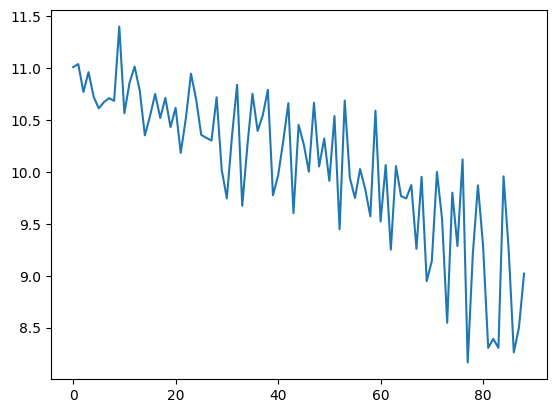

In [ ]:
plt.plot(model.loss_curve_)


Questions 5: (6 points)

Visualize the confusion matrix of actual and predicted data, and mention “True Positive”, “True Negative”, “False Positive” and “False Negative” on the confusion matrix. 
Then, report the following evaluation metrics:

-	Prediction score on test set.
-	F1 Score on Test dataset


[[1958    3]
 [ 536    0]]
F1 Score is 0.0
Accuracy is 0.7841409691629956


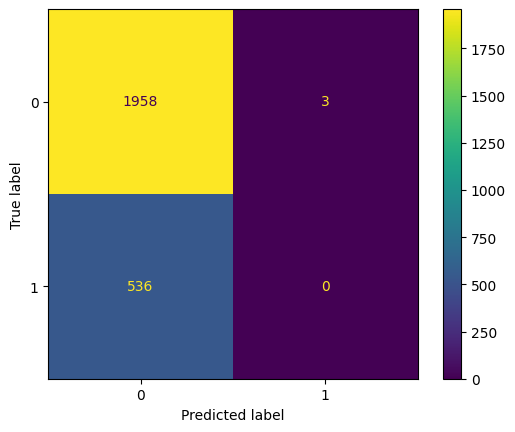

In [ ]:
predicts = model.predict(x_test)
f1 = f1_score(y_test, predicts)
accuracy = accuracy_score(y_test, predicts)
cm = confusion_matrix(y_test, predicts)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()

# print(classification_report(y_test, predicts))
print(f"F1 Score is {f1}")
print(f"Accuracy is {accuracy}")
